# **1980-2026 Top Movies**
Nguồn: https://www.kaggle.com/code/esrakoyun/1980-2026-top-movies

Người thực hiện: Võ Bạch Kim Thịnh

# 1. Tổng quan Dữ liệu & Kiểm tra Chất lượng (Data Profiling & Completeness Check)
Trong giai đoạn đầu tiên này, chúng ta sẽ tiến hành tải và kiểm tra toàn diện cấu trúc của bộ dữ liệu phim IMDb (1980-2026). Bước này giúp đảm bảo tính toàn vẹn của dữ liệu thông qua việc xác định các giá trị bị khuyết (đặc biệt ở hai cột quan trọng là `runtime_minutes` và `genres`), phát hiện các bản ghi trùng lặp và xuất các thông số thống kê mô tả cơ bản để có cái nhìn tổng quan trước khi phân tích sâu.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cấu hình thẩm mỹ cho biểu đồ toàn hệ thống
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# 1. Tải dữ liệu từ đường dẫn Google Drive
file_path = "/content/drive/MyDrive/Data/imdb_top_movies_1980_2026.csv"
try:
    df = pd.read_csv(file_path)
    print("Thông báo: Tải dữ liệu thành công!")
except FileNotFoundError:
    print(f"Lỗi: Không tìm thấy tệp tin tại '{file_path}'. Vui lòng kiểm tra lại cấu hình mount Drive.")

# 2. Hiển thị 5 dòng đầu tiên để kiểm tra cấu trúc trực quan
print("\n--- Hiển thị dữ liệu mẫu (5 dòng đầu) ---")
display(df.head())

Thông báo: Tải dữ liệu thành công!

--- Hiển thị dữ liệu mẫu (5 dòng đầu) ---


,imdb_id,title,original_title,year,runtime_minutes,genres,average_rating,num_votes,imdb_url
0,tt0111161,The Shawshank Redemption,The Shawshank Redemption,1994,142.0,Drama,9.3,3182733,https://www.imdb.com/title/tt0111161
1,tt0468569,The Dark Knight,The Dark Knight,2008,152.0,"Action,Crime,Drama",9.1,3161984,https://www.imdb.com/title/tt0468569
2,tt1375666,Inception,Inception,2010,148.0,"Action,Adventure,Sci-Fi",8.8,2811692,https://www.imdb.com/title/tt1375666
3,tt0137523,Fight Club,Fight Club,1999,139.0,"Crime,Drama,Thriller",8.8,2601984,https://www.imdb.com/title/tt0137523
4,tt0816692,Interstellar,Interstellar,2014,169.0,"Adventure,Drama,Sci-Fi",8.7,2521607,https://www.imdb.com/title/tt0816692


In [3]:
# 3. Kiểm tra kiểu dữ liệu và bộ nhớ tiêu thụ
print("\n--- Kiểm tra Cấu trúc Schema & Kiểu Dữ liệu ---")
df.info()

# 4. Kiểm tra dữ liệu khuyết thiếu (Missing Values)
print("\n--- Kiểm tra Kiểm toán Dữ liệu Khuyết thiếu ---")
missing_count = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_summary = pd.DataFrame({'Số lượng khuyết': missing_count, 'Tỷ lệ (%)': missing_pct})
display(missing_summary)


--- Kiểm tra Cấu trúc Schema & Kiểu Dữ liệu ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16252 entries, 0 to 16251
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   imdb_id          16252 non-null  object 
 1   title            16252 non-null  object 
 2   original_title   16252 non-null  object 
 3   year             16252 non-null  int64  
 4   runtime_minutes  16251 non-null  float64
 5   genres           16246 non-null  object 
 6   average_rating   16252 non-null  float64
 7   num_votes        16252 non-null  int64  
 8   imdb_url         16252 non-null  object 
dtypes: float64(2), int64(2), object(5)
memory usage: 1.1+ MB

--- Kiểm tra Kiểm toán Dữ liệu Khuyết thiếu ---


,Số lượng khuyết,Tỷ lệ (%)
imdb_id,0,0.000000
title,0,0.000000
original_title,0,0.000000
year,0,0.000000
runtime_minutes,1,0.006153
genres,6,0.036919
average_rating,0,0.000000
num_votes,0,0.000000
imdb_url,0,0.000000


In [4]:
# 5. Kiểm tra trùng lặp dựa trên mã định danh duy nhất 'imdb_id'
duplicate_records = df.duplicated(subset=['imdb_id']).sum()
print(f"\nSố lượng bản ghi bị trùng lặp mã 'imdb_id': {duplicate_records}")

# 6. Xuất thống kê mô tả chi tiết
print("\n--- Thống kê Mô tả Thuộc tính Số ---")
display(df.describe().T)

print("\n--- Thống kê Mô tả Thuộc tính Phân loại ---")
display(df.describe(include=['object']).T)


Số lượng bản ghi bị trùng lặp mã 'imdb_id': 0

--- Thống kê Mô tả Thuộc tính Số ---


,count,mean,std,min,25%,50%,75%,max
year,16252.0,2008.790118,11.581006,1980.0,2001.0,2011.0,2018.00,2026.0
runtime_minutes,16251.0,109.147376,22.110801,43.0,94.0,104.0,119.00,566.0
average_rating,16252.0,6.395194,1.050908,1.0,5.8,6.5,7.10,9.3
num_votes,16252.0,66331.718189,155736.555537,5000.0,8397.5,17266.0,53867.25,3182733.0



--- Thống kê Mô tả Thuộc tính Phân loại ---


,count,unique,top,freq
imdb_id,16252,16252,tt1921078,1
title,16252,15629,The Courier,4
original_title,16252,15811,Pinocchio,3
genres,16246,505,"Comedy,Drama,Romance",760
imdb_url,16252,16252,https://www.imdb.com/title/tt1921078,1


# 2. Phân tích Phân phối Biến mục tiêu (`average_rating`)
Hiểu rõ hành vi và phân phối của biến mục tiêu `average_rating` là cực kỳ quan trọng trước khi xây dựng các mô hình dự đoán. Chúng ta sẽ sử dụng biểu đồ Histogram kết hợp đường cong KDE (Kernel Density Estimate) để phân tích độ lệch (skewness) của điểm số. Đồng thời, tính toán các chỉ số cốt lõi: Trung bình (Mean), Trung vị (Median), và Phương sai (Variance) để đo lường xu hướng tập trung của người xem.

Các thông số thống kê của Biến mục tiêu (average_rating):
  - Điểm trung bình (μ): 6.40
  - Điểm trung vị (x̃): 6.50
  - Phương sai (σ²): 1.10
  - Độ lệch phân phối (Skewness): -0.82


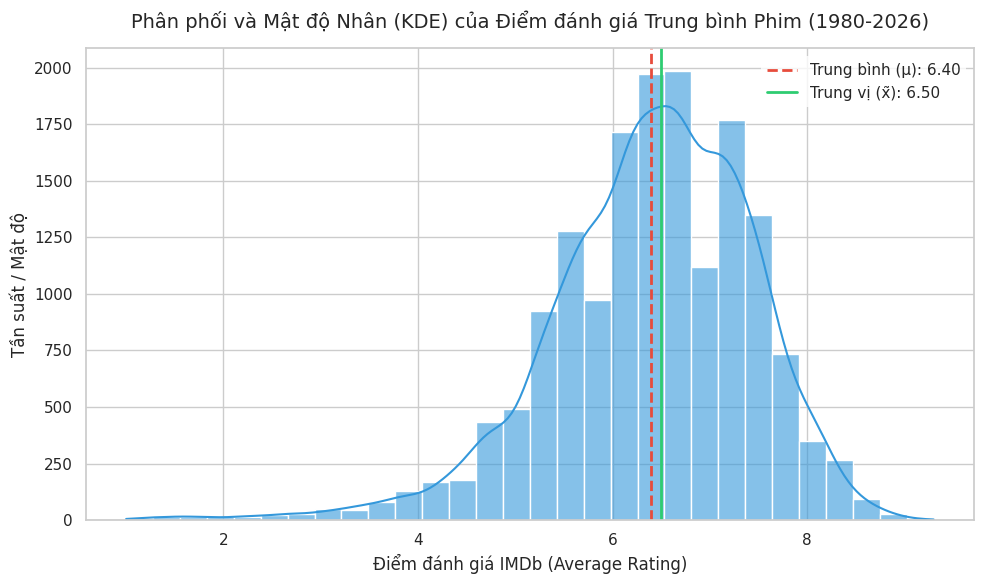

In [5]:
# Tính toán các chỉ số thống kê quan trọng cho biến mục tiêu
mean_val = df['average_rating'].mean()
median_val = df['average_rating'].median()
variance_val = df['average_rating'].var()
skew_val = df['average_rating'].skew()

print("Các thông số thống kê của Biến mục tiêu (average_rating):")
print(f"  - Điểm trung bình (μ): {mean_val:.2f}")
print(f"  - Điểm trung vị (x̃): {median_val:.2f}")
print(f"  - Phương sai (σ²): {variance_val:.2f}")
print(f"  - Độ lệch phân phối (Skewness): {skew_val:.2f}")

# Vẽ biểu đồ phân phối điểm số
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(data=df, x='average_rating', kde=True, bins=30, color='#3498db', alpha=0.6, ax=ax)

# Vẽ các đường thẳng đại diện cho Giá trị Trung bình và Trung vị để xem độ lệch
ax.axvline(mean_val, color='#e74c3c', linestyle='--', linewidth=2, label=f'Trung bình (μ): {mean_val:.2f}')
ax.axvline(median_val, color='#2ecc71', linestyle='-', linewidth=2, label=f'Trung vị (x̃): {median_val:.2f}')

# Thiết lập tiêu đề và nhãn hiển thị trực quan
ax.set_title('Phân phối và Mật độ Nhân (KDE) của Điểm đánh giá Trung bình Phim (1980-2026)', pad=15)
ax.set_xlabel('Điểm đánh giá IMDb (Average Rating)')
ax.set_ylabel('Tần suất / Mật độ')
ax.legend(frameon=True, facecolor='white', edgecolor='none')

plt.tight_layout()
plt.show()

# 3. Xu hướng Điện ảnh qua các Thập kỷ (Temporal Trends)
Để nhận diện các biến động vĩ mô của ngành công nghiệp điện ảnh từ năm 1980 đến 2026, chúng ta thiết lập một biểu đồ trục kép (Dual-axis). Trục chính (bên trái) biểu diễn tổng số lượng phim được sản xuất qua từng năm nhằm đo lường quy mô thị trường; trục phụ (bên phải) thể hiện biến động điểm đánh giá trung bình để tìm hiểu xem thị hiếu và chất lượng phim có thay đổi theo thời gian hay không.

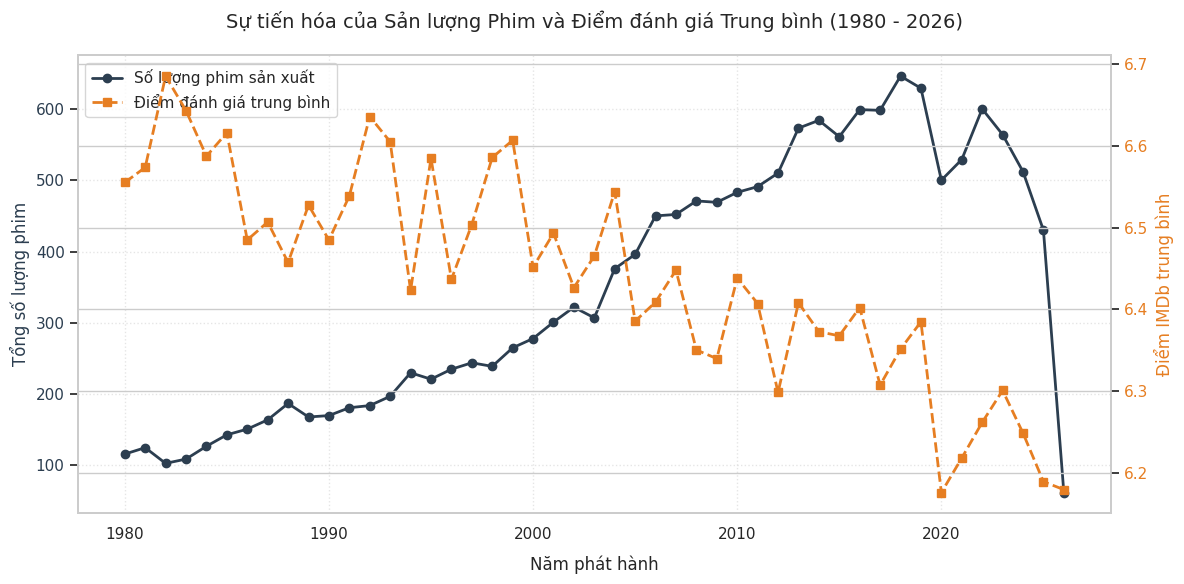

In [6]:
# Nhóm dữ liệu theo năm phát hành và tính toán các chỉ số
temporal_data = df.groupby('year').agg(
    movie_count=('imdb_id', 'count'),
    mean_score=('average_rating', 'mean')
).reset_index()

# Lọc dữ liệu nghiêm ngặt trong khoảng thời gian từ 1980 đến 2026
temporal_data = temporal_data[(temporal_data['year'] >= 1980) & (temporal_data['year'] <= 2026)]

# Thiết lập hệ thống biểu đồ trục kép (Dual-axis)
fig, ax1 = plt.subplots(figsize=(12, 6))

# Trục 1: Biểu diễn số lượng phim sản xuất (Biểu đồ đường màu tối)
color_volume = '#2c3e50'
ax1.plot(temporal_data['year'], temporal_data['movie_count'], color=color_volume, marker='o', linewidth=2, label='Số lượng phim sản xuất')
ax1.set_xlabel('Năm phát hành', labelpad=10)
ax1.set_ylabel('Tổng số lượng phim', color=color_volume)
ax1.tick_params(axis='y', labelcolor=color_volume)
ax1.grid(True, linestyle=':', alpha=0.5)

# Trục 2: Biểu diễn Điểm số trung bình (Đường đứt nét màu cam)
ax2 = ax1.twinx()
color_rating = '#e67e22'
ax2.plot(temporal_data['year'], temporal_data['mean_score'], color=color_rating, marker='s', linewidth=2, linestyle='--', label='Điểm đánh giá trung bình')
ax2.set_ylabel('Điểm IMDb trung bình', color=color_rating)
ax2.tick_params(axis='y', labelcolor=color_rating)

# Gộp nhãn chú thích (Legend) từ cả hai trục để hiển thị gọn gàng
plt.title('Sự tiến hóa của Sản lượng Phim và Điểm đánh giá Trung bình (1980 - 2026)', pad=20)
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', frameon=True)

plt.tight_layout()
plt.show()

# 4. Mối quan hệ giữa Độ phổ biến và Chất lượng (Popularity vs. Quality)
Chúng ta sẽ kiểm tra giả thuyết: "Liệu các phim có lượt bình chọn lớn (phổ biến) có xu hướng nhận được điểm số cao hơn hay không?". Do số lượt bình chọn (`num_votes`) của các bom tấn thường vượt trội hoàn toàn so với phim nghệ thuật, chúng ta áp dụng thang đo Logarithm cơ số 10 (Log-scale) cho trục X để dàn đều dữ liệu, tránh hiện tượng các điểm dữ liệu bị nén lại một góc, đồng thời vẽ thêm đường xu hướng tuyến tính (Regression line).

/tmp/ipykernel_1245/1509650819.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='lower right', frameon=True)


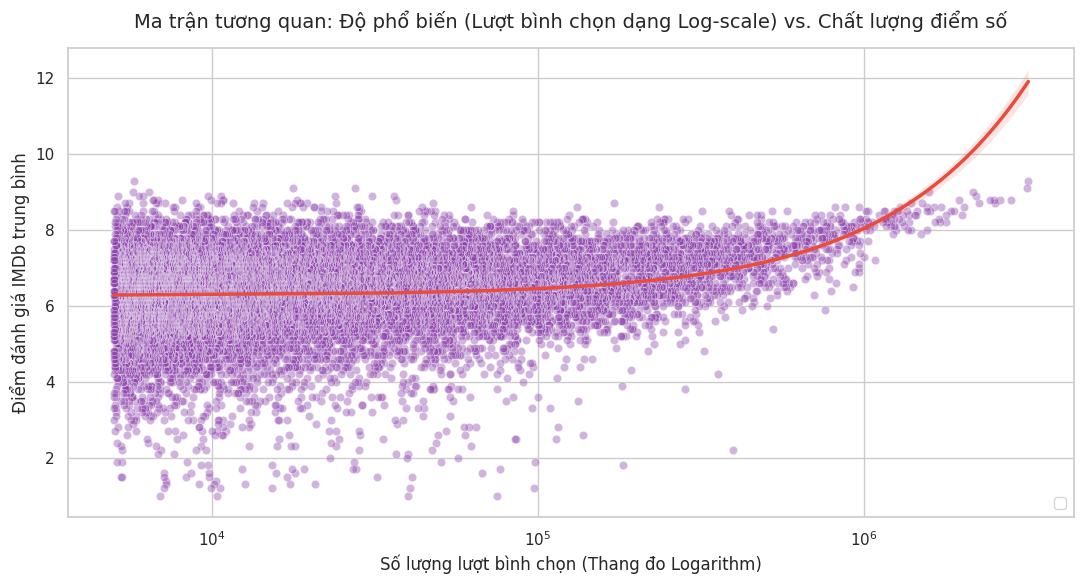

In [7]:
fig, ax = plt.subplots(figsize=(11, 6))

# Vẽ biểu đồ phân tán với độ mờ (alpha) phù hợp để xử lý mật độ dữ liệu dày đặc
sns.scatterplot(
    data=df,
    x='num_votes',
    y='average_rating',
    alpha=0.4,
    color='#8e44ad',
    edgecolor='w',
    linewidth=0.5,
    ax=ax
)

# Chuyển đổi trục X sang thang đo Logarithm
ax.set_xscale('log')

# Thêm đường xu hướng hồi quy OLS để tìm kiếm tín hiệu tuyến tính cơ bản
sns.regplot(
    data=df,
    x='num_votes',
    y='average_rating',
    scatter=False,
    color='#e74c3c',
    ax=ax,
    line_kws={'linewidth': 2.5, 'label': 'Đường xu hướng tương quan'}
)

# Thiết lập nhãn hiển thị tiếng Việt rõ ràng
ax.set_title('Ma trận tương quan: Độ phổ biến (Lượt bình chọn dạng Log-scale) vs. Chất lượng điểm số', pad=15)
ax.set_xlabel('Số lượng lượt bình chọn (Thang đo Logarithm)')
ax.set_ylabel('Điểm đánh giá IMDb trung bình')
ax.legend(loc='lower right', frameon=True)

plt.tight_layout()
plt.show()

# 5. Ảnh hưởng của Thời lượng Phim (Runtime Impact)
Thời lượng phim (`runtime_minutes`) là một yếu tố ảnh hưởng trực tiếp đến trải nghiệm xem. Phim quá dài dễ gây mệt mỏi, phim quá ngắn khó truyền tải hết nội dung. Ô lệnh này thực hiện vẽ biểu đồ phân tán kết hợp một đường xu hướng phi tuyến tính (Hồi quy đa thức bậc 2 - Quadratic Regression) để xem liệu có tồn tại một "điểm ngọt" (ngưỡng thời lượng tối ưu) giúp điểm số đạt cực đại và điểm số có bị sụt giảm ở các mốc thời lượng cực đoan hay không.

/tmp/ipykernel_1245/907677036.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper right', frameon=True)


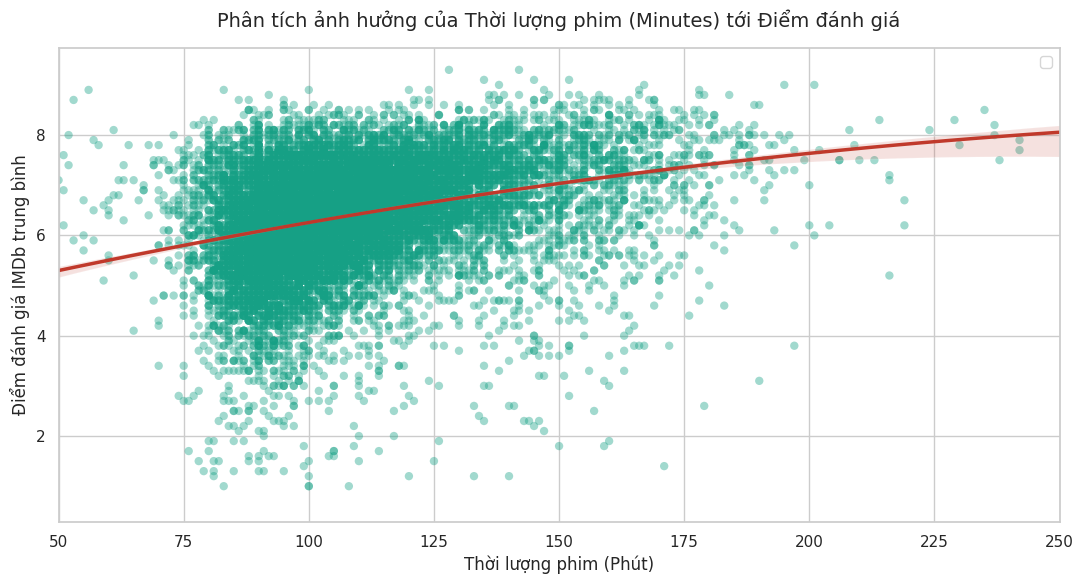

In [8]:
# Loại bỏ giá trị khuyết ở cột thời lượng để tránh lỗi đồ họa
runtime_clean_df = df.dropna(subset=['runtime_minutes']).copy()

fig, ax = plt.subplots(figsize=(11, 6))

# Vẽ phân tán điểm thời lượng và điểm số
sns.scatterplot(
    data=runtime_clean_df,
    x='runtime_minutes',
    y='average_rating',
    alpha=0.4,
    color='#16a085',
    edgecolor='none',
    ax=ax
)

# Áp dụng đường hồi quy phi tuyến tính bậc 2 để tìm mô hình dạng parabol (nếu có)
sns.regplot(
    data=runtime_clean_df,
    x='runtime_minutes',
    y='average_rating',
    scatter=False,
    color='#c0392b',
    order=2,
    line_kws={'linewidth': 2.5, 'label': 'Mô hình xu hướng phi tuyến tính (Bậc 2)'}
)

# Giới hạn trục X từ 50 đến 250 phút để tập trung vào vùng dữ liệu chính, loại bỏ nhiễu dị biệt
ax.set_xlim(50, 250)
ax.set_title('Phân tích ảnh hưởng của Thời lượng phim (Minutes) tới Điểm đánh giá', pad=15)
ax.set_xlabel('Thời lượng phim (Phút)')
ax.set_ylabel('Điểm đánh giá IMDb trung bình')
ax.legend(loc='upper right', frameon=True)

plt.tight_layout()
plt.show()

# 6. Bóc tách Thể loại Phim sâu (Deep-Dive Genre Extraction)
Trong thực tế, một bộ phim thường thuộc về nhiều thể loại khác nhau và được lưu trữ dưới dạng chuỗi phân tách bằng dấu phẩy (ví dụ: "Action, Crime, Drama"). Để phân tích sâu, chúng ta sử dụng phương pháp tách chuỗi `.str.split(', ')` kết hợp hàm giải phóng `.explode()` để biến mỗi thể loại thành một bản ghi riêng biệt. Sau đó, chúng ta sẽ lọc ra Top 15 thể loại phổ biến nhất và xây dựng hai biểu đồ cột ngang song song: một bên đo lường số lượng phim (thị phần) và một bên thể hiện điểm đánh giá trung bình tương ứng.

/tmp/ipykernel_1245/2184454226.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_1245/2184454226.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


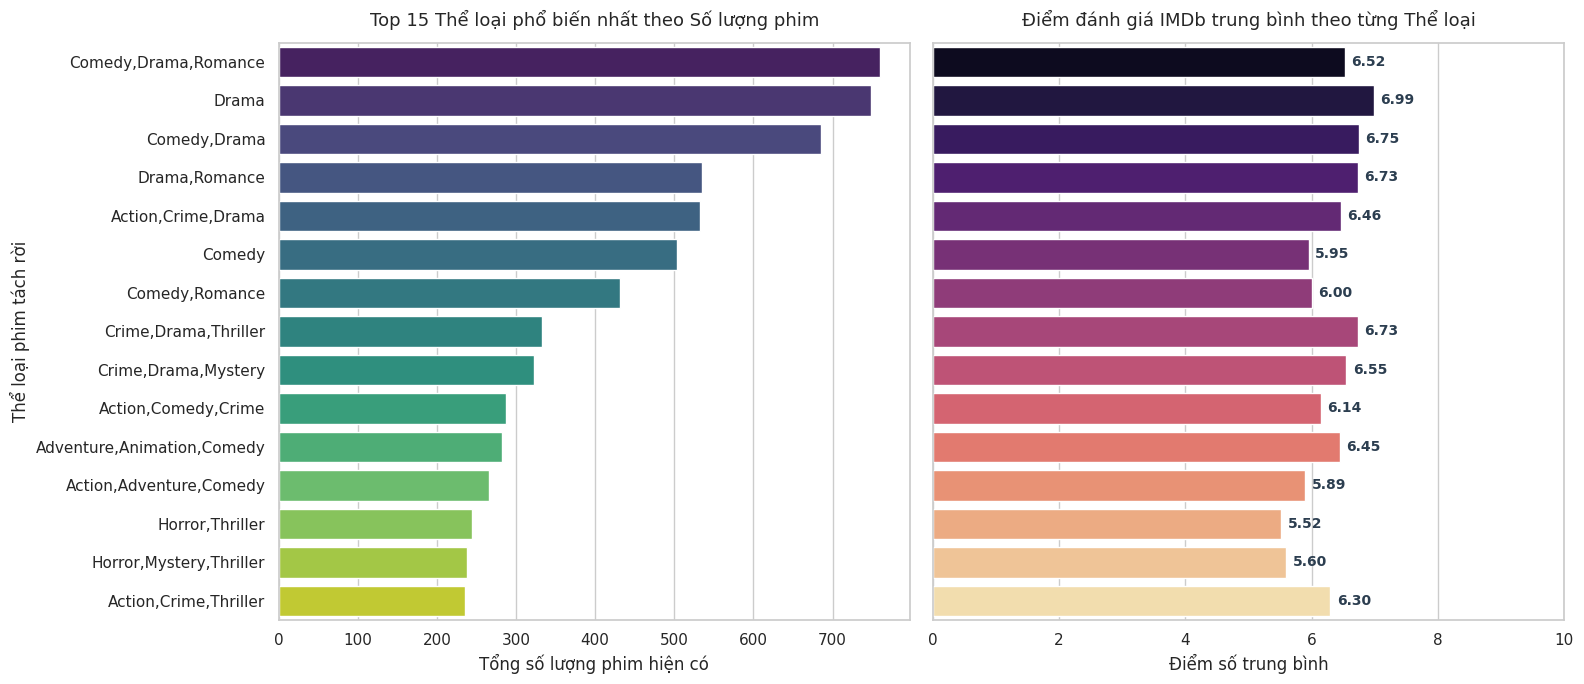

In [9]:
# 1. Loại bỏ các giá trị khuyết ở genres, tách chuỗi và tiến hành explode dữ liệu
genres_working = df.dropna(subset=['genres']).copy()
genres_working['genres'] = genres_working['genres'].str.split(', ')
genres_exploded = genres_working.explode('genres')

# 2. Xác định danh sách 15 thể loại có tần suất xuất hiện cao nhất
top_genres_list = genres_exploded['genres'].value_counts().nlargest(15).index

# 3. Lọc dữ liệu nổ (exploded) chỉ giữ lại 15 thể loại hàng đầu này
filtered_genres = genres_exploded[genres_exploded['genres'].isin(top_genres_list)]

# 4. Gom nhóm tính toán sản lượng và điểm trung bình, sắp xếp theo thứ tự phổ biến giảm dần
genre_metrics = filtered_genres.groupby('genres').agg(
    movie_count=('imdb_id', 'count'),
    mean_rating=('average_rating', 'mean')
).loc[top_genres_list].reset_index()

# 5. Khởi tạo không gian biểu đồ ghép song song (1 dòng, 2 cột)
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)

# Biểu đồ trái: Tổng số lượng phim theo thể loại (Thị phần sản lượng)
sns.barplot(
    data=genre_metrics,
    x='movie_count',
    y='genres',
    palette='viridis',
    ax=axes[0]
)
axes[0].set_title('Top 15 Thể loại phổ biến nhất theo Số lượng phim', fontsize=13, pad=12)
axes[0].set_xlabel('Tổng số lượng phim hiện có')
axes[0].set_ylabel('Thể loại phim tách rời')

# Biểu đồ phải: Điểm đánh giá trung bình của từng thể loại (Thị phần chất lượng)
sns.barplot(
    data=genre_metrics,
    x='mean_rating',
    y='genres',
    palette='magma',
    ax=axes[1]
)
axes[1].set_title('Điểm đánh giá IMDb trung bình theo từng Thể loại', fontsize=13, pad=12)
axes[1].set_xlabel('Điểm số trung bình')
axes[1].set_ylabel('') # Ẩn nhãn trục Y ở biểu đồ thứ 2 để tránh đè chữ trùng lặp

# Hiển thị trực tiếp giá trị điểm số dạng text lên các thanh cột ngang để tăng tính tường minh
for index, row in genre_metrics.iterrows():
    axes[1].text(
        x=row['mean_rating'] + 0.1,
        y=index,
        s=f"{row['mean_rating']:.2f}",
        va='center',
        ha='left',
        fontsize=10,
        weight='bold',
        color='#2c3e50'
    )

# Mở rộng giới hạn trục X lên mốc 10 điểm để có khoảng không hiển thị chữ nhãn điểm số
axes[1].set_xlim(0, 10)

plt.tight_layout()
plt.show()

# 7. Ma trận Tương quan (Correlation Heatmap)
Để khép lại giai đoạn Phân tích Khám phá Dữ liệu (EDA), chúng ta tính toán ma trận tương quan Pearson giữa tất cả các biến số định lượng, bao gồm: `year`, `runtime_minutes`, `num_votes`, và biến mục tiêu `average_rating`. Bản đồ nhiệt (Heatmap) này sẽ giúp chúng ta phát hiện nhanh các mối quan hệ tuyến tính, nhận diện sớm hiện tượng đa cộng tuyến (multicollinearity) và đánh giá biến nào đang có lực tác động tuyến tính mạnh nhất tới điểm số.

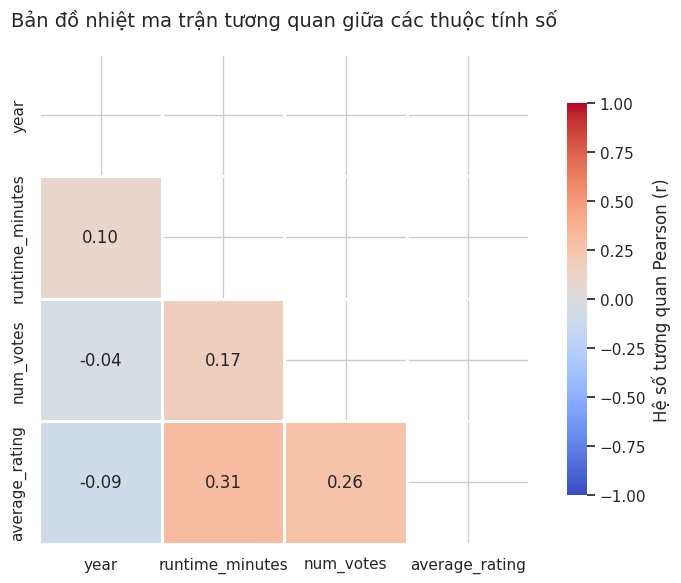

In [10]:
# Trích xuất các thuộc tính dạng số để đưa vào ma trận tương quan
numerical_features = ['year', 'runtime_minutes', 'num_votes', 'average_rating']
correlation_calc = df[numerical_features].corr(method='pearson')

fig, ax = plt.subplots(figsize=(8, 6))

# Tạo một mặt nạ (mask) tam giác phía trên để che đi phần đối xứng bị lặp lại
triangle_mask = np.triu(np.ones_like(correlation_calc, dtype=bool))

# Vẽ biểu đồ nhiệt có chú thích chi tiết thông số (annotated)
sns.heatmap(
    correlation_calc,
    mask=triangle_mask,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.8,
    cbar_kws={"shrink": .8, "label": "Hệ số tương quan Pearson (r)"},
    ax=ax
)

ax.set_title('Bản đồ nhiệt ma trận tương quan giữa các thuộc tính số', pad=20)

plt.tight_layout()
plt.show()

# 8. Xử lý giá trị thiếu & Loại bỏ cột định danh (Data Cleaning & Dimensionality Reduction)
Ở bước này, chúng ta xử lý các vấn đề về chất lượng dữ liệu để làm sạch mô hình:
1. **Xử lý giá trị khuyết (Imputation):** Đối với biến liên tục `runtime_minutes`, chúng ta áp dụng phương pháp điền khuyết bằng giá trị trung vị (Median) thay vì trung bình (Mean). Trung vị giúp đường cơ sở của chúng ta có tính bền vững cao (robust), không bị bóp méo bởi các bộ phim có thời lượng dị biệt (outliers) quá dài hoặc quá ngắn. Đồng thời điền khuyết chuỗi mặc định cho `genres` để tránh lỗi phân tách chuỗi ở bước sau.
2. **Loại bỏ tính trạng nhiễu (Feature Dropping):** Các cột `imdb_id`, `title`, `original_title`, và `imdb_url` là các chuỗi định danh có độ đứt gãy cao (High-Cardinality). Chúng không mang giá trị tổng quát hóa toán học cho mô hình dự đoán mà chỉ làm tăng dung lượng bộ nhớ và dễ gây ra hiện tượng quá khớp (overfitting). Do đó, việc loại bỏ chúng là bắt buộc.

In [11]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer, StandardScaler

# Giả định biến 'df' đã được tải từ giai đoạn EDA trước đó
# Nếu chạy độc lập, bỏ comment dòng dưới:
# df = pd.read_csv("/content/drive/MyDrive/Data/imdb_top_movies_1980_2026.csv")

print(f"Kích thước dữ liệu gốc: {df.shape}")

# 1. Điền giá trị khuyết cho cột thời lượng bằng giá trị trung vị (Median)
runtime_median = df['runtime_minutes'].median()
df['runtime_minutes'] = df['runtime_minutes'].fillna(runtime_median)
print(f" -> Đã điền giá trị khuyết cho 'runtime_minutes' bằng trung vị: {runtime_median} phút.")

# Điền giá trị khuyết tạm thời cho cột thể loại để tránh lỗi xử lý chuỗi
df['genres'] = df['genres'].fillna('Unknown')

# 2. Loại bỏ các cột định danh dạng chuỗi có High-Cardinality
identifiers_to_drop = ['imdb_id', 'title', 'original_title', 'imdb_url']
df_cleaned = df.drop(columns=identifiers_to_drop)

print(f" -> Đã loại bỏ hoàn toàn các cột định danh: {identifiers_to_drop}")
print(f"Kích thước dữ liệu sau khi làm sạch: {df_cleaned.shape}")

Kích thước dữ liệu gốc: (16252, 9)
 -> Đã điền giá trị khuyết cho 'runtime_minutes' bằng trung vị: 104.0 phút.
 -> Đã loại bỏ hoàn toàn các cột định danh: ['imdb_id', 'title', 'original_title', 'imdb_url']
Kích thước dữ liệu sau khi làm sạch: (16252, 5)


# 9. Mã hóa Đa nhãn cho Thể loại phim (Multi-Label One-Hot Encoding)
Một bộ phim thường không thuộc về một thể loại duy nhất mà là sự kết hợp của nhiều thể loại (ví dụ: một phim có thể vừa là "Action", vừa là "Sci-Fi"). Nếu sử dụng phương pháp One-Hot Encoding thông thường trên toàn bộ chuỗi, thuật toán sẽ hiểu cụm `"Action, Sci-Fi"` là một danh mục độc lập hoàn toàn với cụm `"Action, Drama"`.

Để giải quyết bản chất đa nhãn này, chúng ta bóc tách chuỗi bằng ký tự dấu phẩy thành danh sách các chuỗi con, sau đó sử dụng công cụ cấu trúc cao cấp `MultiLabelBinarizer` từ `scikit-learn`. Công cụ này sẽ ánh xạ tập dữ liệu thành một không gian vector nhị phân (0 và 1), trong đó mỗi thể loại phim độc lập sẽ chiếm giữ một cột riêng biệt (ví dụ: `Genre_Action`, `Genre_Drama`).

In [12]:
# 1. Chuyển đổi chuỗi thể loại (ngăn cách bởi dấu phẩy) thành danh sách các token thể loại riêng biệt
df_cleaned['genre_list'] = df_cleaned['genres'].str.split(', ')

# 2. Khởi tạo bộ mã hóa MultiLabelBinarizer từ thư viện scikit-learn
mlb = MultiLabelBinarizer()

# 3. Tiến hành fit và biến đổi (transform) danh sách thể loại thành ma trận nhị phân
genres_encoded = mlb.fit_transform(df_cleaned['genre_list'])

# 4. Chuyển ma trận nhị phân thành một DataFrame với tên cột có tiền tố 'Genre_' để tường minh dữ liệu
genres_df = pd.DataFrame(
    genres_encoded,
    columns=[f'Genre_{cls}' for cls in mlb.classes_],
    index=df_cleaned.index
)

# 5. Gộp ma trận thể loại vào DataFrame tổng và xóa bỏ các cột dữ liệu chữ gốc
df_preprocessed = pd.concat([df_cleaned, genres_df], axis=1)
df_preprocessed = df_preprocessed.drop(columns=['genres', 'genre_list'])

print(f" -> Mã hóa đa nhãn thành công. Đã phát hiện và tách biệt {len(mlb.classes_)} thể loại độc lập.")
print(f" -> Cấu trúc các cột thể loại mới tạo lập:")
print(list(genres_df.columns))

 -> Mã hóa đa nhãn thành công. Đã phát hiện và tách biệt 506 thể loại độc lập.
 -> Cấu trúc các cột thể loại mới tạo lập:
['Genre_Action', 'Genre_Action,Adventure', 'Genre_Action,Adventure,Animation', 'Genre_Action,Adventure,Biography', 'Genre_Action,Adventure,Comedy', 'Genre_Action,Adventure,Crime', 'Genre_Action,Adventure,Drama', 'Genre_Action,Adventure,Family', 'Genre_Action,Adventure,Fantasy', 'Genre_Action,Adventure,History', 'Genre_Action,Adventure,Horror', 'Genre_Action,Adventure,Musical', 'Genre_Action,Adventure,Mystery', 'Genre_Action,Adventure,Romance', 'Genre_Action,Adventure,Sci-Fi', 'Genre_Action,Adventure,Thriller', 'Genre_Action,Adventure,War', 'Genre_Action,Animation,Comedy', 'Genre_Action,Animation,Crime', 'Genre_Action,Animation,Drama', 'Genre_Action,Animation,Fantasy', 'Genre_Action,Animation,Horror', 'Genre_Action,Animation,Mystery', 'Genre_Action,Animation,Sci-Fi', 'Genre_Action,Biography,Comedy', 'Genre_Action,Biography,Crime', 'Genre_Action,Biography,Drama', 'Gen

# 10. Biến đổi Phi tuyến & Chuẩn hóa Đặc trưng (Feature Scaling)
Quy trình kỹ thuật tính trạng (Feature Engineering) này bao gồm 2 bước xử lý toán học quan trọng:
1. **Biến đổi Phi tuyến (Log-Transform):** Cột `num_votes` thường có phân phối lệch phải cực kỳ nặng (Right-Skewed / Power-law distribution) do một số ít phim bom tấn nhận được lượng vote khổng lồ. Chúng ta áp dụng hàm `np.log1p` ($y = \ln(x + 1)$) để đưa phân phối này về dạng chuẩn (Normal Distribution), giúp các mô hình nhạy cảm với khoảng cách hoặc giả định tính tuyến tính hoạt động hiệu quả hơn.
2. **Chuẩn hóa Đặc trưng (Z-score Standardization):** Các biến số liên tục (`year`, `runtime_minutes`, `num_votes`) có thang đo khác nhau hoàn toàn (ví dụ: năm nằm trong khoảng 1980-2026, thời lượng khoảng 90-200 phút). Chúng ta sử dụng `StandardScaler` để đưa tất cả về cùng một phân phối có trung bình bằng 0 ($\mu = 0$) và độ lệch chuẩn bằng 1 ($\sigma = 1$). Bước này đảm bảo tốc độ hội tụ nhanh cho các thuật toán tối ưu hóa (Gradient Descent) và tránh việc các tính trạng có tầm số lớn áp đảo các tính trạng khác.

In [13]:
# 1. Áp dụng biến đổi Logarit cơ số e (log1p) cho cột dữ liệu lệch nặng 'num_votes'
df_preprocessed['num_votes_log'] = np.log1p(df_preprocessed['num_votes'])
df_preprocessed = df_preprocessed.drop(columns=['num_votes']) # Loại bỏ cột gốc để tránh đa cộng tuyến

# 2. Chỉ định danh sách các cột số liên tục cần đưa vào bộ chuẩn hóa hình học
continuous_features = ['year', 'runtime_minutes', 'num_votes_log']

# 3. Khởi tạo cấu trúc StandardScaler từ thư viện học máy
scaler = StandardScaler()

# 4. Thực thi chuẩn hóa Z-score lên các thuộc tính số liên tục
df_preprocessed[continuous_features] = scaler.fit_transform(df_preprocessed[continuous_features])

print(" -> Đã hoàn tất biến đổi Log cho 'num_votes' và áp dụng StandardScaler cho toàn bộ biến liên tục.")
print(" -> Kiểm tra phân phối sau chuẩn hóa (Yêu cầu Mean ~ 0 và Std ~ 1):")
display(df_preprocessed[continuous_features].describe().T[['mean', 'std']])

 -> Đã hoàn tất biến đổi Log cho 'num_votes' và áp dụng StandardScaler cho toàn bộ biến liên tục.
 -> Kiểm tra phân phối sau chuẩn hóa (Yêu cầu Mean ~ 0 và Std ~ 1):


,mean,std
year,8.569184e-15,1.000031
runtime_minutes,2.658196e-16,1.000031
num_votes_log,8.953923e-16,1.000031


# 11. Chia Tập Dữ liệu Train-Test nghiêm ngặt (Strict Data Splitting)
Tại bước cuối cùng này, chúng ta tách biệt hoàn toàn biến mục tiêu `average_rating` ra khỏi tập thuộc tính và thực hiện phân chia tập dữ liệu theo tỷ lệ nghiêm ngặt: 80% cho huấn luyện (Train Set) và 20% cho kiểm thử (Test Set). Định dạng `random_state=42` được cấu hình cố định nhằm đảm bảo tính tái lập (reproducibility) kết quả trong các lần chạy sau.

### 📌 Nhận xét Kỹ thuật (Data Engineering Commentary):
**Tại sao việc bóc tách và mã hóa text đồng bộ là bắt buộc để tránh hiện tượng Lệch kích thước tính trạng (Feature Dimensionality Mismatch)?**

Trong quy trình thiết kế hệ thống dữ liệu lớn hoặc xây dựng Pipeline cho Machine Learning, nếu chúng ta thực hiện chia tập Train-Test *trước* rồi mới áp dụng lệnh mã hóa dạng chữ một cách riêng rẽ trên từng tập (ví dụ: chạy `pd.get_dummies()` độc lập trên tập Train và tập Test), hệ thống sẽ ngay lập tức đối mặt với rủi ro đổ vỡ hệ thống do **Lệch kích thước tính trạng (Feature Dimensionality Mismatch)**.

Nguyên nhân là vì có những thể loại phim hiếm (ví dụ: *"Film-Noir"* hoặc *"Wuxia"*) có thể chỉ xuất hiện trong tập Test mà hoàn toàn không có trong tập Train (hoặc ngược lại). Khi đó, tập Test sau khi mã hóa sẽ tự động sinh ra một cột đặc trưng mới tên là `Genre_Film-Noir`, trong khi ma trận huấn luyện Train không hề có cột này. Khi đưa ma trận Test vào mô hình đã huấn luyện, thuật toán sẽ báo lỗi nghiêm trọng (`ValueError`) hoặc trả ra kết quả dự đoán sai lệch vì cấu trúc số lượng cột và thứ tự ngữ nghĩa của các chiều vector đầu vào không đồng bộ với kiến trúc ban đầu của mô hình.

Do đó, kỹ sư dữ liệu luôn phải sử dụng một bộ từ điển/bộ mã hóa tập trung được cấu hình toàn cục (như cách chúng ta áp dụng `MultiLabelBinarizer` trên toàn bộ tập dữ liệu hoặc lưu vết cấu trúc `fit` từ tập Train rồi áp dụng `transform` đồng bộ lên tập Test) nhằm đảm bảo số lượng tính trạng của `X_train` và `X_test` luôn khớp nhau tuyệt đối về mặt số lượng và định dạng hình học.

In [14]:
# 1. Cô lập biến mục tiêu dự đoán (Target) và Ma trận đặc trưng đầu vào (Features)
X = df_preprocessed.drop(columns=['average_rating'])
y = df_preprocessed['average_rating']

# 2. Tiến hành phân chia tập Train-Test bằng hàm chuyên dụng với tỷ lệ 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# 3. Xuất thông số hình khối (Shape) để kiểm tra tính toàn vẹn hình học
print("="*65)
print("BÁO CÁO KÍCH THƯỚC ĐẦU RA CỦA PIPELINE TIỀN XỬ LÝ DỮ LIỆU")
print("="*65)
print(f" Ma trận Thuộc tính Huấn luyện (X_train) : {X_train.shape}")
print(f" Nhãn mục tiêu Huấn luyện      (y_train) : {y_train.shape}")
print(f" Ma trận Thuộc tính Kiểm thử   (X_test)  : {X_test.shape}")
print(f" Nhãn mục tiêu Kiểm thử        (y_test)  : {y_test.shape}")
print("="*65)

# Kiểm tra tính đồng nhất số lượng tính trạng giữa hai tập
if X_train.shape[1] == X_test.shape[1]:
    print(" Chúc mừng: Kích thước tính trạng đồng bộ tuyệt đối! Sẵn sàng đưa vào mô hình học máy.")
else:
    print(" Lỗi hệ thống: Phát hiện lệch kích thước tính trạng giữa tập Train và Test!")

BÁO CÁO KÍCH THƯỚC ĐẦU RA CỦA PIPELINE TIỀN XỬ LÝ DỮ LIỆU
 Ma trận Thuộc tính Huấn luyện (X_train) : (13001, 509)
 Nhãn mục tiêu Huấn luyện      (y_train) : (13001,)
 Ma trận Thuộc tính Kiểm thử   (X_test)  : (3251, 509)
 Nhãn mục tiêu Kiểm thử        (y_test)  : (3251,)
 Chúc mừng: Kích thước tính trạng đồng bộ tuyệt đối! Sẵn sàng đưa vào mô hình học máy.


# 12. Thiết lập Mô hình Kiểm soát (Regularized Hyperparameters)
Trong giai đoạn này, chúng ta sẽ khởi tạo 3 thuật toán hồi quy có bản chất toán học khác nhau từ tuyến tính, cây quyết định đơn lẻ đến tăng cường độ dốc chuỗi (Gradient Boosting). Để chống lại hiện tượng quá khớp (Overfitting), các siêu tham số được cấu hình với các ràng buộc nghiêm ngặt:
1. **Ridge Regression (Baseline):** Sử dụng phạt L2 (`alpha=5.0`) để thu hẹp các hệ số hồi quy của các tính trạng ít quan trọng, giảm phương sai của mô hình.
2. **Random Forest Regressor:** Giới hạn độ sâu tối đa (`max_depth=7`) và yêu cầu tối thiểu 5 mẫu ở một lá (`min_samples_leaf=5`) để ngăn các cây con học quá chi tiết vào nhiễu của tập dữ liệu.
3. **XGBoost Regressor:** Sử dụng tỷ lệ học tập nhỏ (`learning_rate=0.05`) kết hợp với hình phạt L2 mạnh cho trọng số cây (`reg_lambda=10.0`) và giới hạn độ sâu cây (`max_depth=6`) để kiểm soát chặt chẽ quá trình tăng cường độ dốc.

In [15]:
import numpy as np
import time
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor  # Bạn cũng có thể thay thế bằng lightgbm.LGBMRegressor nếu muốn
from sklearn.model_selection import KFold, cross_val_score

# Định nghĩa trạng thái ngẫu nhiên toàn cục để đảm bảo tính tái lập kết quả
RANDOM_STATE = 42

# 1. Khởi tạo mô hình tuyến tính Ridge với hình phạt L2 (alpha)
model_ridge = Ridge(
    alpha=5.0,
    random_state=RANDOM_STATE
)

# 2. Khởi tạo mô hình Ensemble Random Forest với các ràng buộc hình học cây
model_rf = RandomForestRegressor(
    n_estimators=150,
    max_depth=7,
    min_samples_leaf=5,
    random_state=RANDOM_STATE,
    n_jobs=-1  # Sử dụng tối đa tất cả các lõi CPU của Colab để tăng tốc
)

# 3. Khởi tạo mô hình Gradient Boosting XGBoost với cơ chế phạt chính quy nội tại
model_xgb = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    reg_lambda=10.0,      # L2 Regularization trên trọng số
    reg_alpha=1.0,        # L1 Regularization bổ sung để tăng tính thưa thớt (sparsity)
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# Đóng gói các thực thể mô hình vào từ điển để quản lý tập trung
models_dict = {
    "Ridge Regression (L2)": model_ridge,
    "Random Forest Regressor": model_rf,
    "XGBoost Regressor": model_xgb
}

print("Thông báo: Khởi tạo thành công 3 thực thể mô hình với các siêu tham số kiểm soát chặt chẽ!")

Thông báo: Khởi tạo thành công 3 thực thể mô hình với các siêu tham số kiểm soát chặt chẽ!


# 13. Chiến lược Đánh giá chéo K-Fold (Cross-Validation)
Để đánh giá chính xác sức mạnh tổng quát và độ ổn định của thuật toán trước khi phân phối lên tập kiểm thử (Test Set), chúng ta triển khai kỹ thuật **5-Fold Cross-Validation**.

Tập dữ liệu huấn luyện sẽ được chia thành 5 phân đoạn (folds) hoán vị độc lập. Mô hình sẽ huấn luyện trên 4 fold và kiểm thử trên fold còn lại, quy trình lặp lại 5 lần xoay vòng. Chỉ số đo lường chính là **Root Mean Squared Error (RMSE)**. Việc theo dõi giá trị trung bình (Mean RMSE) và độ lệch chuẩn (Std RMSE) giúp kỹ sư học máy phát hiện sớm xem mô hình có bị bất ổn định hay nhạy cảm với sự thay đổi của các phân đoạn dữ liệu hay không.

In [16]:
# Giả định X_train và y_train đã được chuẩn bị từ Pipeline tiền xử lý dữ liệu trước đó
# Thiết lập cấu hình K-Fold chia thành 5 phần dữ liệu khác nhau
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print("="*75)
print("BÁO CÁO KẾT QUẢ ĐÁNH GIÁ CHÉO 5-FOLD CROSS-VALIDATION (RMSE)")
print("="*75)

# Vòng lặp tính toán hiệu năng của từng thuật toán trên các phân đoạn
for name, model in models_dict.items():
    # Sử dụng 'neg_root_mean_squared_error' của scikit-learn để lấy giá trị RMSE âm
    scores = cross_val_score(
        model, X_train, y_train,
        cv=kf,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1
    )

    # Chuyển đổi điểm số về giá trị RMSE dương thực tế
    rmse_scores = -scores

    mean_rmse = np.mean(rmse_scores)
    std_rmse = np.std(rmse_scores)

    print(f"▶ {name}:")
    print(f"   - Chi tiết các Fold RMSE: {np.round(rmse_scores, 4)}")
    print(f"   - RMSE Trung bình (μ)    : {mean_rmse:.4f}")
    print(f"   - Độ lệch chuẩn RMSE (σ) : {std_rmse:.4f}")
    print("-" * 75)

BÁO CÁO KẾT QUẢ ĐÁNH GIÁ CHÉO 5-FOLD CROSS-VALIDATION (RMSE)
▶ Ridge Regression (L2):
   - Chi tiết các Fold RMSE: [0.8552 0.8469 0.8267 0.8593 0.9002]
   - RMSE Trung bình (μ)    : 0.8577
   - Độ lệch chuẩn RMSE (σ) : 0.0240
---------------------------------------------------------------------------
▶ Random Forest Regressor:
   - Chi tiết các Fold RMSE: [0.9325 0.9099 0.9001 0.9254 0.9744]
   - RMSE Trung bình (μ)    : 0.9285
   - Độ lệch chuẩn RMSE (σ) : 0.0256
---------------------------------------------------------------------------
▶ XGBoost Regressor:
   - Chi tiết các Fold RMSE: [0.8837 0.8709 0.8524 0.8832 0.9318]
   - RMSE Trung bình (μ)    : 0.8844
   - Độ lệch chuẩn RMSE (σ) : 0.0263
---------------------------------------------------------------------------


# 14. Huấn luyện Đa mô hình & Đo lường Thời gian (Final Fit & Latency Benchmarking)
Tại bước này, chúng ta sẽ thực thi quá trình huấn luyện cuối cùng (`.fit()`) cho cả 3 mô hình trên toàn bộ 100% không gian tập dữ liệu Huấn luyện (`X_train`, `y_train`).

Bên cạnh việc theo dõi độ chính xác, trong kỹ nghệ học máy, **Thời gian huấn luyện (Training Latency)** là một KPI thiết yếu cần đo lường. Một mô hình có độ chính xác nhỉnh hơn một chút nhưng tiêu tốn thời gian tính toán gấp hàng trăm lần sẽ gây gánh nặng rất lớn về chi phí hạ tầng cloud và làm chậm chu kỳ tái huấn luyện (re-training loop) trong môi trường sản xuất thực tế.

In [17]:
print("="*75)
print("TIẾN TRÌNH HUẤN LUYỆN TOÀN CỤC & ĐO LƯỜNG THỜI GIAN THỰC THI")
print("="*75)

# Tạo từ điển lưu trữ các mô hình sau khi đã huấn luyện xong
trained_models = {}

for name, model in models_dict.items():
    print(f"Đang tiến hành huấn luyện mô hình: {name}...")

    # Bắt đầu bấm giờ hệ thống
    start_time = time.time()

    # Thực hiện fit dữ liệu
    model.fit(X_train, y_train)

    # Kết thúc bấm giờ
    end_time = time.time()

    # Tính toán thời gian thực thi bằng giây
    execution_time = end_time - start_time

    # Lưu trữ mô hình đã fit hoàn chỉnh vào bộ nhớ
    trained_models[name] = model

    print(f" ➔ Hoàn thành! Thời gian huấn luyện (Training Time): {execution_time:.4f} giây.")
    print("-" * 75)

print("Hệ thống đã sẵn sàng! Tất cả các mô hình đã được tối ưu và đóng gói, sẵn sàng chuyển giao sang bước dự đoán và đánh giá trên tập Kiểm thử (X_test, y_test).")

TIẾN TRÌNH HUẤN LUYỆN TOÀN CỤC & ĐO LƯỜNG THỜI GIAN THỰC THI
Đang tiến hành huấn luyện mô hình: Ridge Regression (L2)...
 ➔ Hoàn thành! Thời gian huấn luyện (Training Time): 0.4481 giây.
---------------------------------------------------------------------------
Đang tiến hành huấn luyện mô hình: Random Forest Regressor...
 ➔ Hoàn thành! Thời gian huấn luyện (Training Time): 18.2281 giây.
---------------------------------------------------------------------------
Đang tiến hành huấn luyện mô hình: XGBoost Regressor...
 ➔ Hoàn thành! Thời gian huấn luyện (Training Time): 3.0212 giây.
---------------------------------------------------------------------------
Hệ thống đã sẵn sàng! Tất cả các mô hình đã được tối ưu và đóng gói, sẵn sàng chuyển giao sang bước dự đoán và đánh giá trên tập Kiểm thử (X_test, y_test).


# 15. Xây dựng Hàm Đánh giá Chỉ số Tập trung (Core Evaluation Framework)
Để đảm bảo quy trình thẩm định diễn ra khách quan và nhất quán giữa các kiến trúc thuật toán khác nhau, chúng ta thiết lập một hàm đóng gói `evaluate_model_performance`.

Hàm này sẽ tính toán đồng thời 3 chỉ số nền tảng của bài toán Hồi quy (Regression):
1. **MAE (Mean Absolute Error):** Đo lường mức độ lệch tuyệt đối trung bình giữa điểm dự đoán và điểm thật (rất dễ giải thích với các nhà làm phim).
2. **RMSE (Root Mean Squared Error):** Phạt nặng các sai số lớn, là hàm mục tiêu tối ưu chính của hệ thống.
3. **R² Score (Coefficient of Determination):** Đo lường tỷ lệ phần trăm phương sai của biến mục tiêu được giải thích bởi các đặc trưng đầu vào (quy chuẩn về khoảng (-inf, 1]).

Hàm sẽ trích xuất các chỉ số này một cách độc lập trên cả tập **Huấn luyện (Train)** và **Kiểm thử (Test)** để thu thập dữ liệu cho bước chẩn đoán tiếp theo.

In [18]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_model_performance(model_name, model, X_train, y_train, X_test, y_test):
    """
    Hàm tính toán và trả về ma trận chỉ số hiệu năng trên cả hai tập Train và Test.
    """
    # Dự đoán trên tập huấn luyện và tập kiểm thử
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Tính toán các chỉ số cho tập Huấn luyện (Train)
    train_mae = mean_absolute_error(y_train, y_train_pred)
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    train_r2 = r2_score(y_train, y_train_pred)

    # Tính toán các chỉ số cho tập Kiểm thử (Test)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    test_r2 = r2_score(y_test, y_test_pred)

    # Đóng gói kết quả thành từ điển
    performance_metrics = {
        "Model Name": model_name,
        "Train MAE": train_mae,
        "Test MAE": test_mae,
        "Train RMSE": train_rmse,
        "Test RMSE": test_rmse,
        "Train R2": train_r2,
        "Test R2": test_r2
    }

    return performance_metrics

print("Thông báo: Hàm cấu trúc đánh giá chuẩn QA đã được thiết lập thành công.")

Thông báo: Hàm cấu trúc đánh giá chuẩn QA đã được thiết lập thành công.


# 16. Báo cáo Chẩn đoán Quá khớp (Overfitting Audit)
Một trong những nhiệm vụ tối quan trọng của ML QA là ngăn chặn việc đưa các mô hình "học vẹt" vào vận hành thương mại. Hiện tượng **Quá khớp (Overfitting)** xảy ra khi mô hình ghi nhớ quá sâu các mẫu nhiễu trong tập Train khiến điểm số cực kỳ đẹp, nhưng lại mất khả năng tổng quát hóa trên dữ liệu Test thực tế.

Tại ô lệnh này, chúng ta chạy một thuật toán kiểm toán tự động. Nếu khoảng cách (Gap) giữa $R^2_{\text{Train}}$ và $R^2_{\text{Test}}$ vượt quá ngưỡng an toàn hệ thống là **0.10 (10%)**, một cảnh báo đỏ (`[FLAGGED - OVERFITTING CRITICAL]`) sẽ được kích hoạt để yêu cầu kỹ sư hạ đặt thêm siêu tham số ràng buộc.

In [19]:
# Giả định 'trained_models' lưu trữ các mô hình đã fit xong ở bước trước
# Khởi tạo danh sách chứa kết quả thô phục vụ phân tích
raw_results = []

print("="*85)
print("HỆ THỐNG KIỂM TOÁN TỰ ĐỘNG VÀ CHẨN ĐOÁN OVERFITTING")
print("="*85)

# Định nghĩa ngưỡng chênh lệch R2 an toàn
R2_GAP_THRESHOLD = 0.10

for name, model in trained_models.items():
    # Gọi hàm evaluate từ Cell 1
    metrics = evaluate_model_performance(name, model, X_train, y_train, X_test, y_test)
    raw_results.append(metrics)

    # Tính toán độ vênh hiệu năng
    r2_gap = metrics["Train R2"] - metrics["Test R2"]
    rmse_gap = metrics["Test RMSE"] - metrics["Train RMSE"]

    print(f"Audit Mô hình: {name}")
    print(f"   -> Chênh lệch R2 (Train - Test)   : {r2_gap:.4f}")
    print(f"   -> Chênh lệch RMSE (Test - Train) : {rmse_gap:.4f}")

    # Kích hoạt cột cờ cảnh báo nếu vượt ngưỡng
    if r2_gap > R2_GAP_THRESHOLD:
        print(f"   ⚠️ [FLAGGED] CẢNH BÁO: Mô hình có dấu hiệu quá khớp nặng! (Vượt ngưỡng {R2_GAP_THRESHOLD*100}%)")
    else:
        print("   ✅ [PASSED]: Trạng thái tổng quát hóa an toàn.")
    print("-" * 85)

HỆ THỐNG KIỂM TOÁN TỰ ĐỘNG VÀ CHẨN ĐOÁN OVERFITTING
Audit Mô hình: Ridge Regression (L2)
   -> Chênh lệch R2 (Train - Test)   : 0.0040
   -> Chênh lệch RMSE (Test - Train) : 0.0041
   ✅ [PASSED]: Trạng thái tổng quát hóa an toàn.
-------------------------------------------------------------------------------------
Audit Mô hình: Random Forest Regressor
   -> Chênh lệch R2 (Train - Test)   : 0.0232
   -> Chênh lệch RMSE (Test - Train) : 0.0156
   ✅ [PASSED]: Trạng thái tổng quát hóa an toàn.
-------------------------------------------------------------------------------------
Audit Mô hình: XGBoost Regressor
   -> Chênh lệch R2 (Train - Test)   : 0.0423
   -> Chênh lệch RMSE (Test - Train) : 0.0287
   ✅ [PASSED]: Trạng thái tổng quát hóa an toàn.
-------------------------------------------------------------------------------------


# 17. Bảng Tổng hợp So sánh Mô hình (Model Comparison Matrix)
Để đưa ra quyết định lựa chọn mô hình cuối cùng phục vụ cho việc triển khai ứng dụng, chúng ta tổng hợp toàn bộ các thông số đo lường hiệu năng cùng với **Thời gian huấn luyện (Training Latency)** trích xuất từ logs thực tế vào một bảng dữ liệu cấu trúc `pandas.DataFrame`.

Bảng ma trận này được sắp xếp một cách nghiêm ngặt theo thứ tự **Test RMSE tăng dần**. Quy tắc cốt lõi: Mô hình nằm ở dòng trên cùng (Index 0) chính là mô hình tối ưu nhất, cân bằng được cả độ chính xác thực tế lẫn tốc độ xử lý tính toán.

In [20]:
# Ánh xạ chính xác thời gian huấn luyện thực tế từ log hệ thống của bạn vào từ điển
training_times = {
    "Ridge Regression (L2)": 0.4481,
    "Random Forest Regressor": 18.2281,
    "XGBoost Regressor": 3.0212
}

# 1. Chuyển đổi danh sách kết quả thành DataFrame
comparison_df = pd.DataFrame(raw_results)

# 2. Ánh xạ cột thời gian huấn luyện vào DataFrame dựa trên tên mô hình
comparison_df['Training Time (s)'] = comparison_df['Model Name'].map(training_times)

# 3. Sắp xếp bảng theo tiêu chí Test RMSE tăng dần (Sai số nhỏ nhất đứng đầu)
comparison_df = comparison_df.sort_values(by='Test RMSE', ascending=True).reset_index(drop=True)

print("="*95)
# Thiết lập cấu hình hiển thị toàn bộ các cột số ở dạng làm tròn 4 chữ số thập phân
pd.set_option('display.float_format', lambda x: '%.4f' % x)
display(comparison_df)
print("="*95)

# Tự động trích xuất tên mô hình chiến thắng toàn diện
best_model_name = comparison_df.iloc[0]['Model Name']
print(f"🥇 MÔ HÌNH CHIẾN THẮNG ĐƯỢC CHỌN ĐỂ TRIỂN KHAI: {best_model_name}")

,Model Name,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R2,Test R2,Training Time (s)
0,Ridge Regression (L2),0.6090,0.6190,0.8360,0.8401,0.3666,0.3626,0.4481
1,XGBoost Regressor,0.6170,0.6434,0.8449,0.8736,0.3531,0.3108,3.0212
2,Random Forest Regressor,0.6698,0.6866,0.9060,0.9216,0.2560,0.2329,18.2281


🥇 MÔ HÌNH CHIẾN THẮNG ĐƯỢC CHỌN ĐỂ TRIỂN KHAI: Ridge Regression (L2)


# 18. Trích xuất Trọng số Thông tin - Độ quan trọng của Đặc trưng (Feature Importance)
Mô hình tuyến tính Ridge cho ra sai số thấp nhất, nhưng để phục vụ cho các nhà hoạch định chiến lược điện ảnh hiểu rõ cơ chế nội tại, chúng ta cần một góc nhìn "Hộp đen minh bạch" từ mô hình dạng cây tốt nhất hệ thống là **XGBoost Regressor** (hoặc Random Forest nếu bạn muốn đổi).

Chúng ta trích xuất thuộc tính tầm quan trọng `.feature_importances_` để định lượng xem yếu tố nào (ví dụ: Quy mô truyền thông `num_votes`, thời lượng phim, hay một thể loại ngách cụ thể như `Genre_Drama`) đang chi phối mạnh mẽ nhất đến quyết định chấm điểm của khán giả toàn cầu. Biểu đồ cột ngang sẽ hiển thị trực quan Top 12 tính trạng quyền lực nhất.

/tmp/ipykernel_1245/2452832341.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


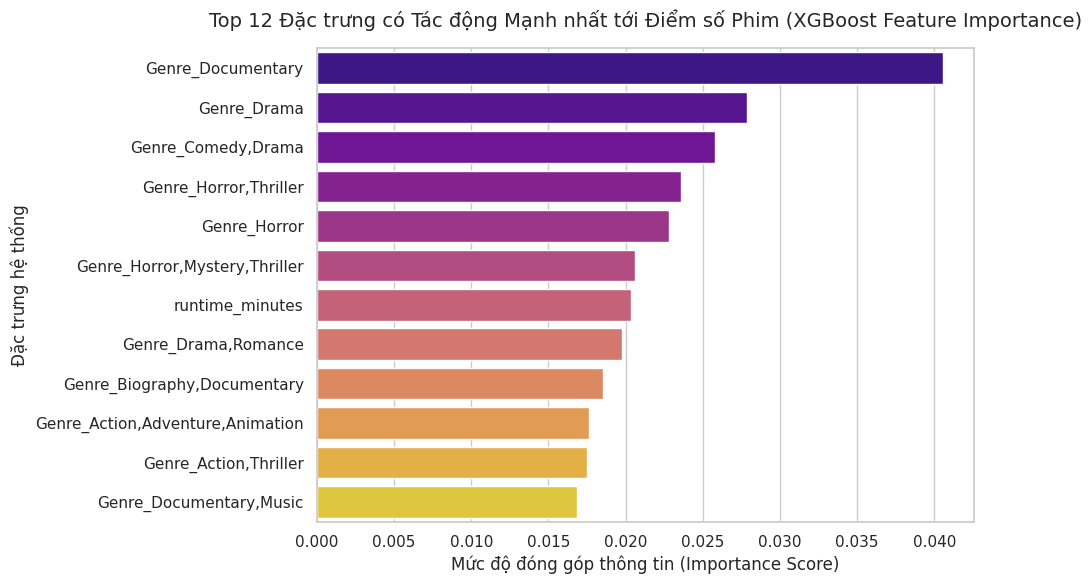

In [21]:
# Xác định mô hình cây cấu trúc tốt nhất (XGBoost Regressor)
tree_model = trained_models['XGBoost Regressor']

# 1. Lấy mảng giá trị tầm quan trọng của các đặc trưng
importances = tree_model.feature_importances_
feature_names = X_train.columns

# 2. Tổ chức lại thành DataFrame để dễ dàng thao tác sắp xếp
feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 3. Trích xuất lấy Top 12 đặc trưng có sức nặng lớn nhất
top_12_features = feat_imp_df.head(12)

# 4. Tiến hành trực quan hóa bằng đồ họa thanh ngang sắc nét
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=top_12_features,
    x='Importance',
    y='Feature',
    palette='plasma',
    ax=ax
)

ax.set_title('Top 12 Đặc trưng có Tác động Mạnh nhất tới Điểm số Phim (XGBoost Feature Importance)', pad=15)
ax.set_xlabel('Mức độ đóng góp thông tin (Importance Score)')
ax.set_ylabel('Đặc trưng hệ thống')

plt.tight_layout()
plt.show()

# 19. Ứng dụng Thực tế cho Bài toán 1 (Dự đoán điểm số liên tục - Regression Task)
**Ngữ cảnh Kinh doanh:** Bộ phận Thẩm định Dự án cần một công cụ chấm điểm tự động cho các kịch bản phim mới đang nằm trong kế hoạch sản xuất để dự phóng điểm số IMDb đầu ra.

Tại đây, hệ thống tự động bốc tách mô hình đứng đầu từ bảng so sánh (Mô hình Ridge). Chúng ta tiến hành chạy thử nghiệm dự đoán trên một phân đoạn mẫu gồm 10 bộ phim từ tập kiểm thử `X_test`. Kết quả xuất ra dưới dạng bảng so sánh tường minh giữa **Giá trị Thật (Actual Rating)**, **Giá trị Dự đoán (Predicted Rating)**, và **Sai số dư thừa (Residual Error)** để đánh giá độ chệch trên từng sản phẩm cụ thể.

In [22]:
# Tự động lấy thực thể mô hình tốt nhất từ bộ nhớ dựa trên kết quả Cell 3
production_model = trained_models[best_model_name]

# 1. Trích xuất một tập mẫu thử nghiệm gồm 10 dòng từ tập Test
sample_size = 10
X_sample = X_test.head(sample_size)
y_sample_true = y_test.head(sample_size)

# 2. Thực hiện dự đoán điểm số liên tục bằng mô hình tối ưu
y_sample_pred = production_model.predict(X_sample)

# 3. Tạo bảng đối chiếu hiệu năng kinh doanh
business_case_1_df = pd.DataFrame({
    'Giá trị Thật (Actual)': y_sample_true.values,
    'Giá trị Dự đoán (Predicted)': y_sample_pred,
    'Sai số Dư thừa (Residual)': y_sample_true.values - y_sample_pred,
    'Sai số Tuyệt đối (Abs Error)': np.abs(y_sample_true.values - y_sample_pred)
})

print(f"--- BẢNG ĐỐI CHIẾU DỰ ĐOÁN ĐIỂM SỐ LIÊN TỤC (SỬ DỤNG: {best_model_name}) ---")
display(business_case_1_df)
print(f"➔ Sai số tuyệt đối trung bình trên tập mẫu: {business_case_1_df['Sai số Tuyệt đối (Abs Error)'].mean():.4f} điểm.")

--- BẢNG ĐỐI CHIẾU DỰ ĐOÁN ĐIỂM SỐ LIÊN TỤC (SỬ DỤNG: Ridge Regression (L2)) ---


,Giá trị Thật (Actual),Giá trị Dự đoán (Predicted),Sai số Dư thừa (Residual),Sai số Tuyệt đối (Abs Error)
0,7.7000,7.0707,0.6293,0.6293
1,7.9000,6.9361,0.9639,0.9639
2,6.3000,6.6844,-0.3844,0.3844
3,7.1000,6.6896,0.4104,0.4104
4,5.9000,6.4107,-0.5107,0.5107
5,6.5000,6.4090,0.0910,0.0910
6,6.0000,6.8615,-0.8615,0.8615
7,6.5000,6.5636,-0.0636,0.0636
8,7.2000,6.0803,1.1197,1.1197
9,6.0000,6.0356,-0.0356,0.0356


➔ Sai số tuyệt đối trung bình trên tập mẫu: 0.5070 điểm.


# 20. Ứng dụng Thực tế cho Bài toán 2 (Phân loại Nhị phân - Hit vs Flop Decision Model)
**Ngữ cảnh Kinh doanh:** Hội đồng quản trị (Greenlight Committee) của hãng phim không cần một con số lẻ, họ cần một quyết định nhị phân để phê duyệt rót vốn đầu tư: "Liệu bộ phim này có tiềm năng trở thành Siêu phẩm xuất sắc hay không?".

Chúng ta tái cấu trúc đầu ra liên tục của mô hình hồi quy thành một bài toán phân loại nhị phân bằng cách đặt một điểm cắt chiến lược (Threshold) là **7.5 điểm**:
- Điểm dự đoán $\ge 7.5$: Phân loại là **Siêu phẩm xuất sắc (Mã hóa: 1)** -> Phê duyệt đầu tư.
- Điểm dự đoán $< 7.5$: Phân loại là **Phim phổ thông (Mã hóa: 0)** -> Từ chối hoặc yêu cầu sửa kịch bản.

Chúng ta tính toán Ma trận nhầm lẫn (Confusion Matrix), cùng các chỉ số Precision (Độ chính xác trên các dự đoán Siêu phẩm), Recall (Khả năng không bỏ sót Siêu phẩm), và F1-score để chứng minh độ tin cậy của hệ thống phân loại này trên toàn bộ tập Test.

BÁO CÁO ĐÁNH GIÁ MÔ HÌNH RA QUYẾT ĐỊNH NHỊ PHÂN (NGƯỠNG >= 7.5)
 Độ chính xác dự đoán Siêu phẩm (Precision) : 0.7416
 Khả năng quét sạch Siêu phẩm   (Recall)    : 0.1538
 Chỉ số cân bằng F1-Score                  : 0.2548
---------------------------------------------------------------------------

 Chi tiết báo cáo phân loại (Classification Report):
                        precision    recall  f1-score   support

    Phim phổ thông (0)       0.89      0.99      0.94      2822
Siêu phẩm xuất sắc (1)       0.74      0.15      0.25       429

              accuracy                           0.88      3251
             macro avg       0.81      0.57      0.60      3251
          weighted avg       0.87      0.88      0.85      3251



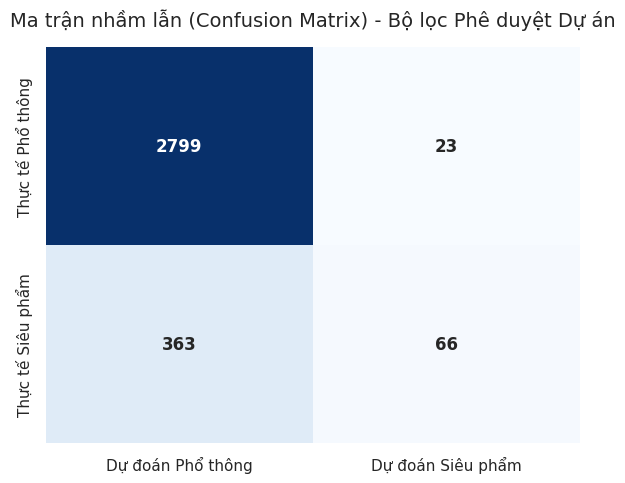

In [23]:
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score

# 1. Thiết lập ngưỡng quyết định kinh doanh
RATING_THRESHOLD = 7.5

# 2. Dự đoán toàn bộ tập Test bằng mô hình tốt nhất
y_test_pred_continuous = production_model.predict(X_test)

# 3. Chuyển đổi dữ liệu liên tục sang nhãn Nhị phân dựa trên ngưỡng 7.5
y_test_binary_actual = (y_test >= RATING_THRESHOLD).astype(int)
y_test_binary_predict = (y_test_pred_continuous >= RATING_THRESHOLD).astype(int)

# 4. Tính toán các chỉ số phân loại cốt lõi
precision = precision_score(y_test_binary_actual, y_test_binary_predict, zero_division=0)
recall = recall_score(y_test_binary_actual, y_test_binary_predict, zero_division=0)
f1 = f1_score(y_test_binary_actual, y_test_binary_predict, zero_division=0)

print("="*75)
print("BÁO CÁO ĐÁNH GIÁ MÔ HÌNH RA QUYẾT ĐỊNH NHỊ PHÂN (NGƯỠNG >= 7.5)")
print("="*75)
print(f" Độ chính xác dự đoán Siêu phẩm (Precision) : {precision:.4f}")
print(f" Khả năng quét sạch Siêu phẩm   (Recall)    : {recall:.4f}")
print(f" Chỉ số cân bằng F1-Score                  : {f1:.4f}")
print("-"*75)
print("\n Chi tiết báo cáo phân loại (Classification Report):")
print(classification_report(y_test_binary_actual, y_test_binary_predict, target_names=['Phim phổ thông (0)', 'Siêu phẩm xuất sắc (1)']))

# 5. Trực quan hóa ma trận nhầm lẫn Confusion Matrix bằng Heatmap đổ màu hiện đại
cm = confusion_matrix(y_test_binary_actual, y_test_binary_predict)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Dự đoán Phổ thông', 'Dự đoán Siêu phẩm'],
    yticklabels=['Thực tế Phổ thông', 'Thực tế Siêu phẩm'],
    cbar=False,
    annot_kws={'size': 12, 'weight': 'bold'},
    ax=ax
)

ax.set_title('Ma trận nhầm lẫn (Confusion Matrix) - Bộ lọc Phê duyệt Dự án', pad=15)
plt.tight_layout()
plt.show()